### Load Fashion-MNIST

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
(x_train, _), (_, _) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 127.5 - 1.0
x_train = x_train.reshape(x_train.shape[0], 784)

df = pd.DataFrame(x_train)
df.to_csv("fashion_mnist_data.csv", index=False)

#reload
data = pd.read_csv("fashion_mnist_data.csv").values

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 23s 5us/step


Generator:

In [4]:
latent_dim = 100

generator = keras.Sequential([
    layers.Dense(256, activation="relu", input_shape=(latent_dim,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(784, activation="tanh")
])

f:\Anaconda\envs\notebook\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Discriminator

In [5]:
discriminator = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

GAN

In [6]:
discriminator.trainable = False

gan_input = layers.Input(shape=(latent_dim,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)

gan = keras.Model(gan_input, gan_output)

gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy"
)

training

In [9]:
epochs = 60
batch_size = 64
half_batch = batch_size // 2

for epoch in range(epochs):
    
    # real 
    idx = np.random.randint(0, data.shape[0], half_batch)
    real_imgs = data[idx]

    # fake 
    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    if epoch % 5 == 0:
        print("Epoch", epoch, "| "
            "D Loss:", float(d_loss_real[0]), "| "
            "D Acc:", float(d_loss_real[1])*100, "% | "
            "G Loss:", g_loss)

Epoch 0 | D Loss: 0.6581792235374451 | D Acc: 63.12500238418579 % | G Loss: [array(0.75601006, dtype=float32), array(0.75601006, dtype=float32), array(0.5260417, dtype=float32)]
Epoch 5 | D Loss: 1.07448148727417 | D Acc: 50.20833611488342 % | G Loss: [array(1.2145879, dtype=float32), array(1.2145879, dtype=float32), array(0.47070312, dtype=float32)]
Epoch 10 | D Loss: 1.5677804946899414 | D Acc: 48.374998569488525 % | G Loss: [array(1.7099316, dtype=float32), array(1.7099316, dtype=float32), array(0.46514422, dtype=float32)]
Epoch 15 | D Loss: 2.025298833847046 | D Acc: 47.410714626312256 % | G Loss: [array(2.1498823, dtype=float32), array(2.1498823, dtype=float32), array(0.4609375, dtype=float32)]
Epoch 20 | D Loss: 2.4146931171417236 | D Acc: 47.01388776302338 % | G Loss: [array(2.5215151, dtype=float32), array(2.5215151, dtype=float32), array(0.45991847, dtype=float32)]
Epoch 25 | D Loss: 2.7183640003204346 | D Acc: 46.590909361839294 % | G Loss: [array(2.813648, dtype=float32), ar

In [10]:
idx = np.random.randint(0, data.shape[0], 500)
real_imgs = data[idx]

noise = np.random.normal(0, 1, (500, latent_dim))
fake_imgs = generator.predict(noise, verbose=0)

d_loss_real = discriminator.evaluate(real_imgs, np.ones((500, 1)), verbose=0)
d_loss_fake = discriminator.evaluate(fake_imgs, np.zeros((500, 1)), verbose=0)

final_acc = (d_loss_real[1] + d_loss_fake[1]) / 2

print("Final Discriminator Accuracy:", final_acc * 100)

Final Discriminator Accuracy: 44.999998807907104


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


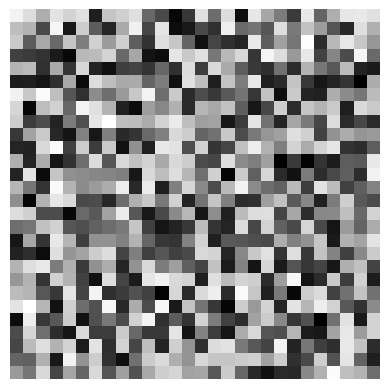

In [10]:
noise = np.random.normal(0, 1, (1, latent_dim))
generated_img = generator.predict(noise)

generated_img = generated_img.reshape(28, 28)

plt.imshow(generated_img, cmap="gray")
plt.axis("off")
plt.show()